# Bias Detection and Fairness 

NovaCred has received a regulatory inquiry regarding potential discrimination in its credit decision process. The following notebook will inspect NovaCred's historical credit application data, uncovering possible evidence of algorithmic bias and unfair practices in past credit decisions. While automation of such processes can improve consistency and speed, it also carries the risk of perpetuating historical discrimination patterns embedded in the data.

The following sections will therefore focus on: 
- **Gender Disparity:** Quantifying approval rate differences between gender groups and calculating the Disparate Impact (DI) ratio in accordance with the four-fifths rule.
- **Age-Based Bias:** Examining how approval rates and loan terms vary across age groups to detect potential discrimination against younger or older applicants.
- **Proxy Discrimination:** Investigating whether neutral variables such as ZIP code or spending behavior indirectly encode protected characteristics and influence decisions.
- **Interaction Effects:** Exploring combined effects of multiple protected attributes (e.g., gender and age) to reveal compounding disadvantages that isolated analyses may miss.
- **Loan Term Fairness:** Assessing whether approved interest rates and loan amounts differ systematically across groups with otherwise comparable financial profiles.

In [24]:
# Necessary imports
# Data manipulation 
import pandas as pd
import numpy as np
import os
from scipy import stats

# Data Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Fairness
from fairlearn.metrics import demographic_parity_difference


First, we import and inspect the cleaned data that was transmitted by our data engineers. 

In [2]:
# Load cleaned dataset
data_path = os.path.join("..", "data", "cleaned_credit_applications.csv")
df = pd.read_csv(data_path)

print(f"Dataset shape: {df.shape[0]} rows × {df.shape[1]} columns")
df.head()

Dataset shape: 500 rows × 25 columns


,_id,spending_behavior,processing_timestamp,loan_purpose,notes,applicant_info_full_name,applicant_info_email,applicant_info_ssn,applicant_info_ip_address,applicant_info_gender,...,financials_savings_balance,decision_loan_approved,decision_rejection_reason,decision_interest_rate,decision_approved_amount,financials_annual_salary,financials_annual_income_canonical,analysis_dob_format,analysis_dob_parsed,analysis_age_years
0,app_200,"[{'category': 'Shopping', 'amount': 480}, {'ca...",2024-01-15T00:00:00Z,NaN,NaN,Jerry Smith,jerry.smith17@hotmail.com,596-64-4340,192.168.48.155,Male,...,31212.0,False,algorithm_risk_score,NaN,NaN,NaN,73000.0,YYYY-MM-DD (ISO),2001-03-09,24.985626
1,app_037,"[{'category': 'Rent', 'amount': 608}, {'catego...",NaN,NaN,NaN,Brandon Walker,brandon.walker2@yahoo.com,425-69-4784,10.1.102.112,Male,...,17915.0,False,algorithm_risk_score,NaN,NaN,NaN,78000.0,YYYY-MM-DD (ISO),1992-03-31,33.924709
2,app_215,"[{'category': 'Rent', 'amount': 109}]",NaN,vacation,NaN,Scott Moore,scott.moore94@mail.com,370-78-5178,10.240.193.250,Male,...,37909.0,True,NaN,3.7,59000.0,NaN,61000.0,YYYY-MM-DD (ISO),1989-10-24,36.358658
3,app_024,"[{'category': 'Fitness', 'amount': 575}]",NaN,NaN,NaN,Thomas Lee,thomas.lee6@protonmail.com,194-35-1833,192.168.175.67,Male,...,0.0,True,NaN,4.3,34000.0,NaN,103000.0,YYYY-MM-DD (ISO),1983-04-25,42.858316
4,app_184,"[{'category': 'Entertainment', 'amount': 463}]",2024-01-15T00:00:00Z,NaN,NaN,Brian Rodriguez,brian.rodriguez86@aol.com,480-41-2475,172.29.125.105,Male,...,31763.0,False,algorithm_risk_score,NaN,NaN,NaN,57000.0,YYYY-MM-DD (ISO),1999-05-21,26.787132


As in the following need for transformation still might arise, we will copy the cleaned dataframe.

In [3]:
df_bias = df.copy()

## Gender Disparity 
Gender is a protected attribute under EU anti-discrimination law and is considered a sensitive characteristic under the EU AI Act, especially since credit scoring systems are classified as high-risk AI applications. It is therefore important to examine whether NovaCred’s historical lending decisions show systematic differences in approval outcomes across gender groups, even if gender is not directly used as a model input.

To assess this, we calculate the Disparate Impact (DI) Ratio, defined as:

$$DI = \frac{\text{Approval Rate (unprivileged group)}}{\text{Approval Rate (privileged group)}}$$

A DI ratio of 1.0 indicates equal approval rates. According to the commonly applied four-fifths rule, a DI below 0.8 suggests potential disparate impact, meaning one group is approved significantly less often than another.

The following analysis uses the columns: 
- `applicant_info_gender`: records the self-reported gender of each applicant, which serves as the protected attribute in this analysis
- `decision_loan_approved`: records the final lending decision for each application as a binary value,`True` if the loan was approved, `False` if it was denied

### Data Preperation
Before calculating the DI ratio, we inspect both columns for inconsistencies and apply the necessary transformations to ensure they are ready for analysis.

In [4]:
print(df_bias["applicant_info_gender"].value_counts())
print(df_bias["applicant_info_gender"].isna().sum())

print(f"Records of gender entries: {len(df_bias)}")

applicant_info_gender
Female     251
Male       247
Unknown      2
Name: count, dtype: int64
0
Records of gender entries: 500


In [5]:
df_bias = df_bias[df_bias["applicant_info_gender"] != "Unknown"]
print(f"Records after removing unknown gender entries: {len(df_bias)}")

Records after removing unknown gender entries: 498


Two observations were labeled as "Unknown" for gender and were excluded from the analysis, as for the Disparate Impact calculation we need the clearly defined comparision groups (unpriviledged and priviledged).

In [6]:
print(df_bias["decision_loan_approved"].value_counts())
print(df_bias["decision_loan_approved"].dtype)

decision_loan_approved
True     290
False    208
Name: count, dtype: int64
bool


`decision_loan_approved` contains only clean `True/False` boolean values and requires no further cleaning. 

### Disparate Impact Ratio 
We now calculate the Disparate Impact ratio to formally quantify the difference in approval rates between female and male applicants.

In [11]:
# Approval rates by gender
rates = df_bias.groupby('applicant_info_gender')['decision_loan_approved'].mean ()
female_rate = rates['Female'] 
male_rate = rates['Male'] 

print(f'Female rate: {female_rate:.4f}')
print(f'Male rate: {male_rate:.4f}')

# DI Ratio
di_ratio = female_rate/male_rate 

print(f"Disparate Impact Ratio: {di_ratio:.4f}")
print("Potential disparate impact detected!" if di_ratio < 0.8 else "DI ratio within acceptable range.")

Female rate: 0.5060
Male rate: 0.6599
Disparate Impact Ratio: 0.7667
Potential disparate impact detected!


The analysis yields a female approval rate of 50.6% compared to 66.0% for male applicants, which is a gap of over 15 percentage points. With a DI ratio of 0.767, the result falls below the four-fifths threshold of 0.8, indicating potential disparate impact against female applicants.

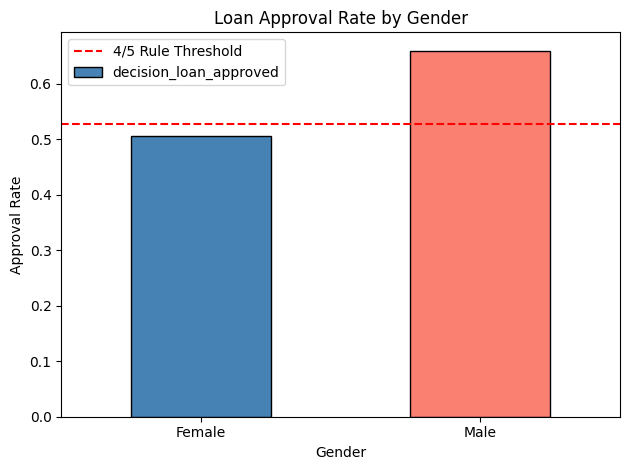

                       Total  Approved  Approval_Rate
applicant_info_gender                                
Female                   251       127         0.5060
Male                     247       163         0.6599


In [13]:
# Visualization: Bar chart by approval rate by gender
import matplotlib.pyplot as plt

rates.plot(kind="bar", color=["steelblue", "salmon"], edgecolor="black")
plt.title("Loan Approval Rate by Gender")
plt.xlabel("Gender")
plt.ylabel("Approval Rate")
plt.xticks(rotation=0)
plt.axhline(y=male_rate * 0.8, color="red", linestyle="--", label="4/5 Rule Threshold")
plt.legend()
plt.tight_layout()
plt.show()

# Summary Table 
summary = df_bias.groupby("applicant_info_gender")["decision_loan_approved"].agg(
    Total="count",
    Approved="sum",
    Approval_Rate="mean"
).round(4)
print(summary)

The bar chart clearly illustrates that female applicants are approved at a meaningfully lower rate than male applicants, with the female approval rate falling below the four-fifths rule threshold marked by the red dashed line. While this pattern is concerning, a disparity in approval rates alone does not conclusively prove discriminatory bias. It is possible that legitimate financial differences between groups, such as lower average income or higher debt-to-income ratios among female applicants, partially explain the gap. However, if the 
disparity persists after controlling for financial profile, it would constitute stronger evidence of bias. This effect will be looked at in a later stage of this notebook through proxy analysis and interaction effects.

### Statistical significance - z-test

A DI ratio below 0.8 is a meaningful signal, but with a dataset of 498 applications it is important to verify that the observed difference in approval rates is statistically significant and not simply due to random variation. We apply a **two-proportion z-test**, as it is the standard method for comparing two independent proportions.

Hypothesis:

- **H₀ (Null Hypothesis):** There is no difference in approval rates between female and male applicants
- **H₁ (Alternative Hypothesis):** Female applicants have a significantly lower approval rate than male applicants

A p-value below 0.05 would allow us to reject the null hypothesis and treat the observed disparity as statistically significant.

In [14]:
from statsmodels.stats.proportion import proportions_ztest

# Get counts
gender_groups = df_bias.groupby("applicant_info_gender")["decision_loan_approved"]
n_female   = gender_groups.get_group("Female").count()
n_male     = gender_groups.get_group("Male").count()
app_female = gender_groups.get_group("Female").sum()
app_male   = gender_groups.get_group("Male").sum()

# Two-proportion z-test
count = np.array([app_female, app_male])
nobs  = np.array([n_female, n_male])
z_stat, p_value = proportions_ztest(count, nobs, alternative="smaller")

print(f"Z-statistic : {z_stat:.4f}")
print(f"P-value     : {p_value:.4f}")
print("Statistically significant disparity detected (p < 0.05)." if p_value < 0.05 
      else "No statistically significant disparity detected.")

Z-statistic : -3.4828
P-value     : 0.0002
Statistically significant disparity detected (p < 0.05).


**Findings**: 
The analysis shows a clear difference in loan approval rates between female (50.6%) and male (66.0%) applicants. The Disparate Impact ratio is 0.767, which falls below the four-fifths threshold of 0.8 and therefore signals potential discrimination. The two-proportion z-test (z = -3.48, p = 0.0002) indicates that this difference is statistically significant and very unlikely to be due to random chance. Overall, this suggests a relevant fairness concern that should be examined more closely in the following sections.

## Age-based Bias
Age is also a protected characteristic under EU anti-discrimination law. If lending decisions systematically disadvantage applicants simply because they are younger or older, this raises a fairness concern, even if age is not directly used in the model. Similar to gender, age-related bias can still appear indirectly through other variables that are correlated with age.

The following analysis uses:
- `analysis_age_years`: the applicant's age in years, derived from `applicant_info_date_of_birth` by the Data Engineering pipeline
- `decision_loan_approved`: the binary outcome variable (approved/denied)
- `decision_interest_rate`: to assess whether approved loan terms differ across age groups
- `decision_approved_amount`: to assess whether loan amounts differ across age groups

### Data Preperation
The `analysis_age_years` variable was already created in the Data Engineering pipeline based on `applicant_info_date_of_birth`. We checked it for missing values and removed 3 observations where age could not be calculated, since age group classification requires a valid numeric value. Age groups are then created based on the cleaned age variable since it is a continuous variable and enable group-level comparisons of approval rates.

The variables `applicant_info_gender` and `decision_loan_approved` were already reviewed and cleaned in the Gender Analysis. The `variables decision_interest_rate` and `decision_approved_amount` were validated in the data quality notebook. Both contain 207 missing values, which occur exclusively for denied applications and are therefore consistent with the dataset design and do not require further adjustment.

In [ ]:
# Inspecting missing values or impossible ages 
print(df_bias["analysis_age_years"].describe())
print(f"\nMissing values: {df_bias['analysis_age_years'].isna().sum()}")
print(f"\nAge range: {df_bias['analysis_age_years'].min():.0f} - {df_bias['analysis_age_years'].max():.0f} years")

print(f"Records after removing missing age values: {len(df_bias)}")

count    495.000000
mean      41.204671
std       10.924274
min       23.860370
25%       32.431211
50%       39.485284
75%       47.481177
max       67.449692
Name: analysis_age_years, dtype: float64

Missing values: 3

Age range: 24 - 67 years


In [19]:
# dropping the 3 rows with missing age values 
df_bias = df_bias.dropna(subset=["analysis_age_years"])
print(f"Records after removing missing age values: {len(df_bias)}")

Records after removing missing age values: 495


In [ ]:
# Define age bins and labels
bins   = [18, 30, 45, 60, 100]
labels = ["18-30", "31-45", "46-60", "60+"]

df_bias["age_group"] = pd.cut(
    df_bias["analysis_age_years"],
    bins=bins,
    labels=labels,
    right=True
)

print(df_bias["age_group"].value_counts().sort_index())

age_group
18-30     82
31-45    257
46-60    113
60+       43
Name: count, dtype: int64

Missing age groups: 0


C:\Users\lilik\AppData\Local\Temp\ipykernel_25488\730745656.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_bias["age_group"] = pd.cut(


In [23]:
# Inspect interest rate and approved amount
print(f"Missing values: {df_bias['decision_interest_rate'].isna().sum()}")

print(f"Missing values: {df_bias['decision_approved_amount'].isna().sum()}")

Missing values: 207
Missing values: 207


### Age-based discrimination patterns

**Continuous Age Effect**: 
Before examining age groups, we first investigate whether a continuous relationship exists between age and loan approval. This avoids any artificial bias introduced by age group boundaries and reveals the overall direction of any age-related pattern. We use a 
point-biserial correlation coefficient, which is the appropriate measure for testing the relationship between a continuous variable (age) and a binary outcome (approved/denied).

- **H₀:** There is no correlation between age and loan approval
- **H₁:** There is a significant correlation between age and loan approval

Point-Biserial Correlation: 0.1220
P-value                   : 0.0066
Significant correlation detected (p < 0.05).


C:\Users\lilik\AppData\Local\Temp\ipykernel_25488\1630289536.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


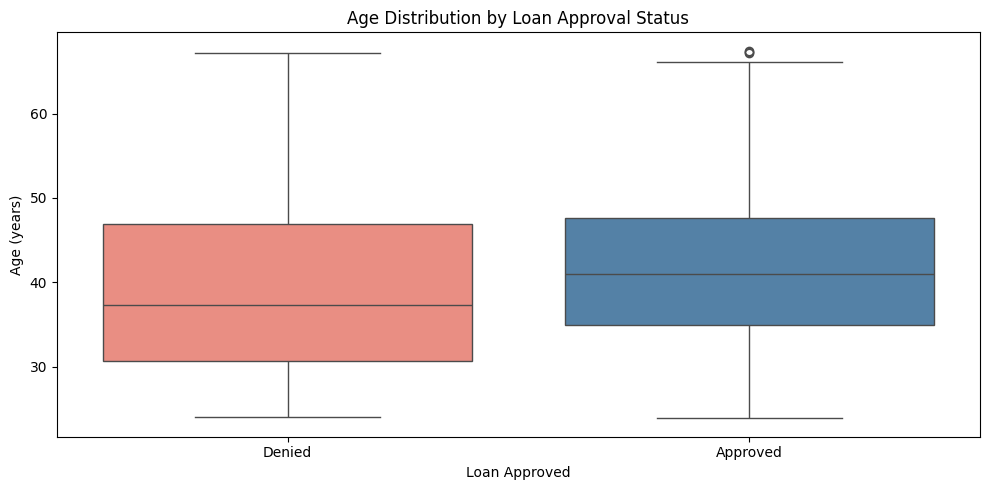

In [25]:
# Point-biserial correlation between age and approval
corr, p_value = stats.pointbiserialr(
    df_bias["analysis_age_years"],
    df_bias["decision_loan_approved"]
)

print(f"Point-Biserial Correlation: {corr:.4f}")
print(f"P-value                   : {p_value:.4f}")
print("Significant correlation detected (p < 0.05)." if p_value < 0.05
      else "No significant correlation detected.")

# Visualization: Age distribution by approval status
plt.figure(figsize=(10, 5))
sns.boxplot(
    data=df_bias,
    x="decision_loan_approved",
    y="analysis_age_years",
    palette=["salmon", "steelblue"]
)
plt.title("Age Distribution by Loan Approval Status")
plt.xlabel("Loan Approved")
plt.ylabel("Age (years)")
plt.xticks([0, 1], ["Denied", "Approved"])
plt.tight_layout()
plt.show()

The point-biserial correlation (r = 0.122, p = 0.0066) shows a small but statistically significant positive relationship between age and loan approval, indicating that older applicants are slightly more likely to be approved. The box plot supports this pattern, with approved applicants having a somewhat higher median age (~41) than denied applicants (~38). Although the effect is modest, it appears unlikely to be due to chance and suggests a potential disadvantage for younger applicants.

**Approval Rate Differences Across Age Groups**: Building on the continuous age effect, we now examine approval rates across the four 
defined age groups to identify which specific groups are most affected. A chi-square test of independence is used to assess whether the observed differences in approval rates across age groups are statistically significant.

- **H₀:** Loan approval is independent of age group
- **H₁:** Loan approval is significantly associated with age group

In [28]:
# Approval rates by age group
age_approval = df_bias.groupby("age_group")["decision_loan_approved"].agg(
    total="count",
    approved="sum",
    rate="mean"
).round(3)
print(age_approval)

           total  approved   rate
age_group                        
18-30         82        34  0.415
31-45        257       156  0.607
46-60        113        70  0.619
60+           43        28  0.651


C:\Users\lilik\AppData\Local\Temp\ipykernel_25488\3511492160.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  age_approval = df_bias.groupby("age_group")["decision_loan_approved"].agg(


In [ ]:
# DI Ratio for age groups
max_rate = age_approval["Approval_Rate"].max()
min_rate = age_approval["Approval_Rate"].min()
di_age   = min_rate / max_rate

print(f"\nHighest approval rate : {max_rate:.4f} ({age_approval['Approval_Rate'].idxmax()})")
print(f"Lowest approval rate  : {min_rate:.4f} ({age_approval['Approval_Rate'].idxmin()})")
print(f"Disparate Impact Ratio: {di_age:.4f}")
print("Potential disparate impact detected!" if di_age < 0.8 
      else "DI ratio within acceptable range.")

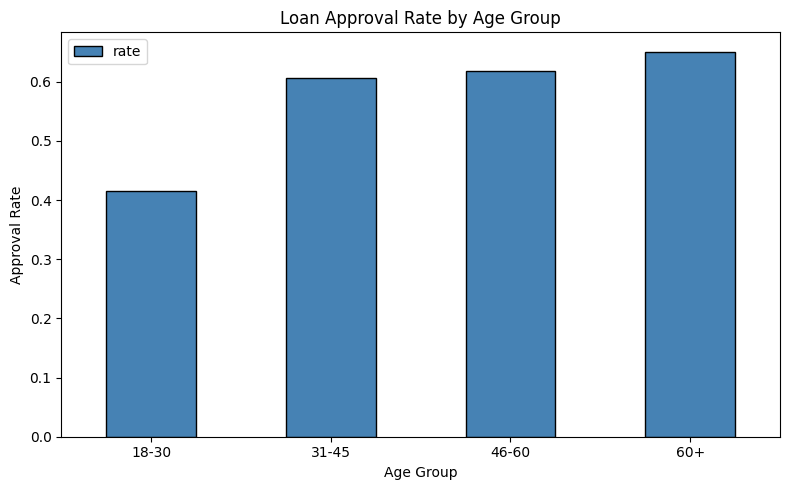

In [29]:
# Visualization: Bar chart of approval rates by age group
age_approval["rate"].plot(
    kind="bar", 
    color="steelblue", 
    edgecolor="black",
    figsize=(8, 5)
)
plt.title("Loan Approval Rate by Age Group")
plt.xlabel("Age Group")
plt.ylabel("Approval Rate")
plt.xticks(rotation=0)
#plt.axhline(y=max_rate * 0.8, color="red", linestyle="--", label="4/5 Rule Threshold")
plt.legend()
plt.tight_layout()
plt.show()

In [30]:
# Chi-square test of independence
from scipy.stats import chi2_contingency

contingency_table = pd.crosstab(
    df_bias["age_group"], 
    df_bias["decision_loan_approved"]
)
chi2, p_value, dof, expected = chi2_contingency(contingency_table)

print(f"\nChi-square statistic : {chi2:.4f}")
print(f"Degrees of freedom   : {dof}")
print(f"P-value              : {p_value:.4f}")
print("Significant association detected (p < 0.05)." if p_value < 0.05
      else "No significant association detected.")


Chi-square statistic : 11.5983
Degrees of freedom   : 3
P-value              : 0.0089
Significant association detected (p < 0.05).


**Interest rates across age groups**

**Approved amounts across age groups**:

### Statistical significance - 

## Proxy Discrimination

## Interaction Effects 